# 05 · Multiclass on Real Datasets
Same functions as the previous notebook, from scratch · NumPy for the model · matplotlib for graphs · Runs on Google Colab

| # | Dataset | Task | Features | Classes |
|---|---|---|---|---|
| 1 | Iris | Flower species | 4 | 3 |
| 2 | Wine | Grape cultivar from chemical analysis | 13 | 3 |
| 3 | Handwritten digits | Which digit (8×8 image) | 64 | 10 |

## The model (same as before): input ➜ hidden (tanh) ➜ output (softmax)

| Function | What it does |
|---|---|
| `mlp_forward_pass(x, net)` | $h = \tanh(x \cdot W_1)$, $p = \text{softmax}(h \cdot W_2)$ |
| `compute_error(y, p)` | $y - p$ |
| `mlp_backward_pass(net, x, error, cache, lr)` | $\delta_{hidden} = (W_2 \cdot \text{error}) \cdot \tanh'(s_1)$, then $W \leftarrow W - \eta \cdot dW$ |

In [1]:
import io, urllib.request
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
np.set_printoptions(precision=3, suppress=True)

def add_x0(X):
    return np.hstack([-np.ones((len(X), 1)), X])                  # x0 = -1, so w0 is the threshold

def softmax(s):
    e = np.exp(s - s.max())
    return e / e.sum()

def cross_entropy(Y, P):
    return -np.mean(np.log(np.sum(Y * P, axis=1) + 1e-12))

def new_net(n_in, hidden, n_out):
    return {"W1": rng.uniform(-0.5, 0.5, (n_in + 1, hidden)), "W2": rng.uniform(-0.5, 0.5, (hidden + 1, n_out))}

def mlp_forward_pass(x, net):
    s1 = x @ net["W1"]
    h = np.r_[-1, np.tanh(s1)]                                    # h0 = -1 for the output thresholds
    return softmax(h @ net["W2"]), (s1, h)

def compute_error(y, p):
    return y - p

def mlp_backward_pass(net, x, error, cache, lr):
    s1, h = cache
    delta_hidden = (net["W2"][1:] @ error) * (1 - np.tanh(s1) ** 2)
    dW2 = -np.outer(h, error)
    dW1 = -np.outer(x, delta_hidden)
    return {"W1": net["W1"] - lr * dW1, "W2": net["W2"] - lr * dW2}

def mlp_probs(X0, net):
    H = np.hstack([-np.ones((len(X0), 1)), np.tanh(X0 @ net["W1"])])
    S = H @ net["W2"]
    E = np.exp(S - S.max(axis=1, keepdims=True))
    return E / E.sum(axis=1, keepdims=True)

def accuracy(X0, y, net):
    return 100 * (mlp_probs(X0, net).argmax(axis=1) == y).mean()


def mlp_train(X0, y, net, lr, epochs, show=True):
    Y = np.eye(net["W2"].shape[1])[y]                             # one-hot targets
    losses = []
    for epoch in range(1, epochs + 1):
        for i in rng.permutation(len(X0)):                        # shuffle the order every epoch
            p, cache = mlp_forward_pass(X0[i], net)
            net = mlp_backward_pass(net, X0[i], compute_error(Y[i], p), cache, lr)
        losses.append(cross_entropy(Y, mlp_probs(X0, net)))
        if show and (epoch == 1 or epoch % max(1, epochs // 5) == 0):
            print(f"Epoch {epoch:3d} | loss {losses[-1]:.4f} | train accuracy {accuracy(X0, y, net):5.1f}%")
    return net, losses

## Helpers: load, split, scale, confusion matrix

In [2]:
def load_csv(url, skip_header=0):
    text = urllib.request.urlopen(url).read().decode()
    return np.genfromtxt(io.StringIO(text), delimiter=",", dtype=str, skip_header=skip_header)

def split(X, y, test_ratio=0.2):
    idx = rng.permutation(len(X))
    n_test = int(len(X) * test_ratio)
    return X[idx[n_test:]], X[idx[:n_test]], y[idx[n_test:]], y[idx[:n_test]]

def scale(X_train, X_test):
    mean, std = X_train.mean(axis=0), X_train.std(axis=0) + 1e-9  # train statistics only
    return (X_train - mean) / std, (X_test - mean) / std

def show_confusion(X0, y, net, names, title):
    pred = mlp_probs(X0, net).argmax(axis=1)
    k = len(names)
    cm = np.zeros((k, k), dtype=int)
    for t, p in zip(y, pred):
        cm[t, p] += 1
    fig, ax = plt.subplots(figsize=(1 + 0.6 * k, 1 + 0.6 * k))
    ax.imshow(cm, cmap="Blues")
    for i in range(k):
        for j in range(k):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set(xticks=range(k), yticks=range(k), xticklabels=names, yticklabels=names,
           xlabel="predicted", ylabel="actual", title=f"{title}: {100 * (pred == y).mean():.1f}% correct")
    plt.setp(ax.get_xticklabels(), rotation=45)
    plt.show()

def show_predictions(X0, y, net, names, n=5):
    for p, t in zip(mlp_probs(X0[:n], net), y[:n]):
        print(f"probabilities {p} -> predicted {names[p.argmax()]:>12} | true {names[t]:>12} {'✓' if p.argmax() == t else '✗'}")

---
# 1. Iris: 3 species from 4 measurements

In [3]:
iris = load_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv", skip_header=1)
X_iris = iris[:, :4].astype(float)
iris_names = [str(s) for s in np.unique(iris[:, 4])]
y_iris = np.array([iris_names.index(s) for s in iris[:, 4]])
print("Shape:", X_iris.shape, "| classes:", iris_names, "| per class:", np.bincount(y_iris))

Xtr, Xte, ytr, yte = split(X_iris, y_iris)
Xtr, Xte = scale(Xtr, Xte)
iris_tr0, iris_te0 = add_x0(Xtr), add_x0(Xte)

Shape: (150, 4) | classes: ['setosa', 'versicolor', 'virginica'] | per class: [50 50 50]


Epoch   1 | loss 0.3641 | train accuracy  85.8%
Epoch  10 | loss 0.0622 | train accuracy  97.5%
Epoch  20 | loss 0.0565 | train accuracy  98.3%
Epoch  30 | loss 0.0687 | train accuracy  96.7%
Epoch  40 | loss 0.0506 | train accuracy  98.3%
Epoch  50 | loss 0.0567 | train accuracy  97.5%

Test accuracy: 96.7%

probabilities [0.    0.028 0.972] -> predicted    virginica | true   versicolor ✗
probabilities [0.002 0.998 0.   ] -> predicted   versicolor | true   versicolor ✓
probabilities [0.    0.073 0.927] -> predicted    virginica | true    virginica ✓
probabilities [0.999 0.001 0.   ] -> predicted       setosa | true       setosa ✓
probabilities [0.    0.038 0.962] -> predicted    virginica | true    virginica ✓


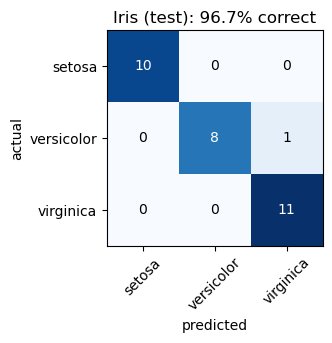

In [4]:
iris_net, _ = mlp_train(iris_tr0, ytr, new_net(4, 8, 3), lr=0.05, epochs=50)
print(f"\nTest accuracy: {accuracy(iris_te0, yte, iris_net):.1f}%\n")
show_predictions(iris_te0, yte, iris_net, iris_names)
show_confusion(iris_te0, yte, iris_net, iris_names, "Iris (test)")

---
# 2. Wine: 3 cultivars from 13 chemical measurements

In [5]:
wine = load_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data").astype(float)
X_wine, y_wine = wine[:, 1:], wine[:, 0].astype(int) - 1      # classes 1, 2, 3 -> 0, 1, 2
wine_names = ["cultivar 1", "cultivar 2", "cultivar 3"]
print("Shape:", X_wine.shape, "| per class:", np.bincount(y_wine))
print("Feature ranges (min ... max):", X_wine.min(axis=0).round(1), "...", X_wine.max(axis=0).round(1))

wine_tr_raw, wine_te_raw, ytr_w, yte_w = split(X_wine, y_wine)
Xtr_w, Xte_w = scale(wine_tr_raw, wine_te_raw)
wine_tr0, wine_te0 = add_x0(Xtr_w), add_x0(Xte_w)

Shape: (178, 13) | per class: [59 71 48]
Feature ranges (min ... max): [ 11.    0.7   1.4  10.6  70.    1.    0.3   0.1   0.4   1.3   0.5   1.3
 278. ] ... [  14.8    5.8    3.2   30.   162.     3.9    5.1    0.7    3.6   13.
    1.7    4.  1680. ]


Epoch   1 | loss 0.1016 | train accuracy  99.3%
Epoch  10 | loss 0.0091 | train accuracy 100.0%
Epoch  20 | loss 0.0041 | train accuracy 100.0%
Epoch  30 | loss 0.0026 | train accuracy 100.0%
Epoch  40 | loss 0.0019 | train accuracy 100.0%
Epoch  50 | loss 0.0015 | train accuracy 100.0%

Test accuracy: 100.0%

probabilities [0.    0.173 0.826] -> predicted   cultivar 3 | true   cultivar 3 ✓
probabilities [0. 1. 0.] -> predicted   cultivar 2 | true   cultivar 2 ✓
probabilities [0. 0. 1.] -> predicted   cultivar 3 | true   cultivar 3 ✓
probabilities [0.994 0.006 0.   ] -> predicted   cultivar 1 | true   cultivar 1 ✓
probabilities [0. 0. 1.] -> predicted   cultivar 3 | true   cultivar 3 ✓


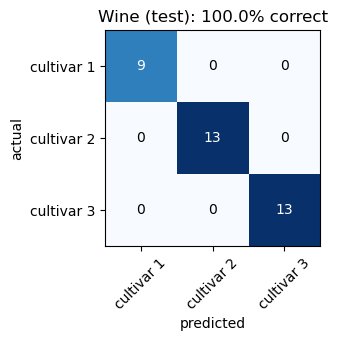

In [6]:
wine_net, _ = mlp_train(wine_tr0, ytr_w, new_net(13, 10, 3), lr=0.05, epochs=50)
print(f"\nTest accuracy: {accuracy(wine_te0, yte_w, wine_net):.1f}%\n")
show_predictions(wine_te0, yte_w, wine_net, wine_names)
show_confusion(wine_te0, yte_w, wine_net, wine_names, "Wine (test)")

---
# 3. Handwritten digits: 10 classes from 8×8 images

train: (3823, 64), test: (1797, 64) | per digit (train): [376 389 380 389 387 376 377 387 380 382]


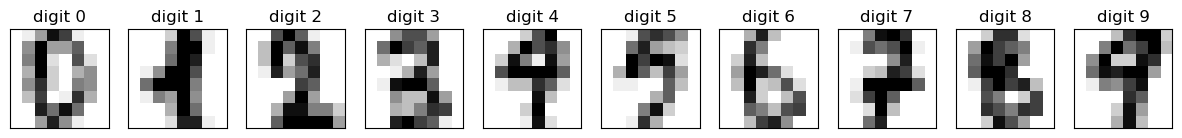

In [7]:
base = "https://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/"
d_tr = load_csv(base + "optdigits.tra").astype(int)
d_te = load_csv(base + "optdigits.tes").astype(int)
Xd_tr, yd_tr = d_tr[:, :64] / 16, d_tr[:, 64]                     # pixel values 0..16 -> 0..1
Xd_te, yd_te = d_te[:, :64] / 16, d_te[:, 64]
digit_names = [str(d) for d in range(10)]
print(f"train: {Xd_tr.shape}, test: {Xd_te.shape} | per digit (train): {np.bincount(yd_tr)}")

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for d, ax in enumerate(axes):
    ax.imshow(Xd_tr[yd_tr == d][0].reshape(8, 8), cmap="gray_r")
    ax.set(title=f"digit {d}", xticks=[], yticks=[])
plt.show()

digits_tr0, digits_te0 = add_x0(Xd_tr), add_x0(Xd_te)

Epoch   1 | loss 0.1780 | train accuracy  95.3%
Epoch   4 | loss 0.0818 | train accuracy  97.9%
Epoch   8 | loss 0.0429 | train accuracy  99.1%
Epoch  12 | loss 0.0332 | train accuracy  99.1%
Epoch  16 | loss 0.0201 | train accuracy  99.6%
Epoch  20 | loss 0.0148 | train accuracy  99.8%

Test accuracy: 96.5%


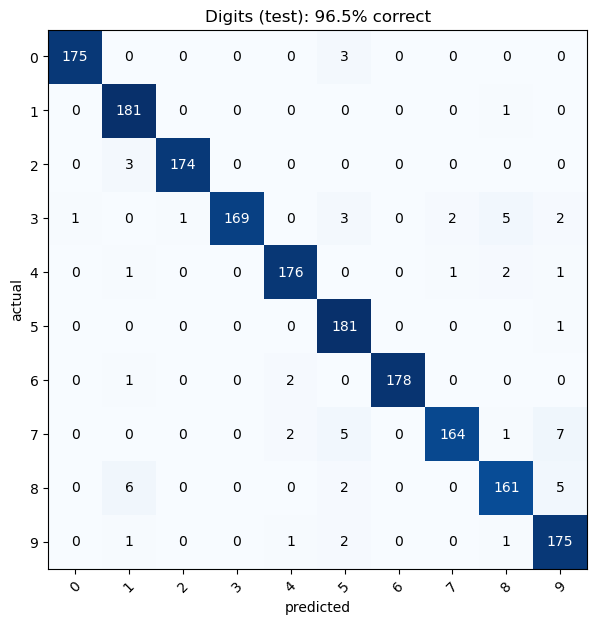

In [8]:
digit_net, _ = mlp_train(digits_tr0, yd_tr, new_net(64, 32, 10), lr=0.02, epochs=20)
print(f"\nTest accuracy: {accuracy(digits_te0, yd_te, digit_net):.1f}%")
show_confusion(digits_te0, yd_te, digit_net, digit_names, "Digits (test)")

## Mistakes the network made

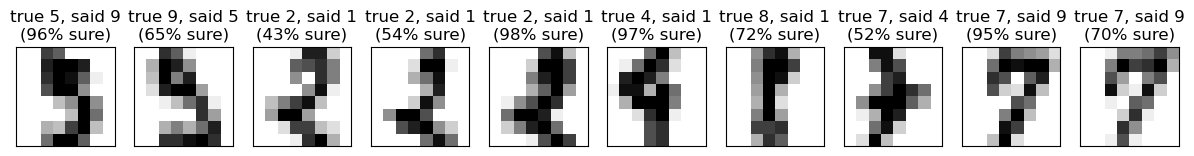

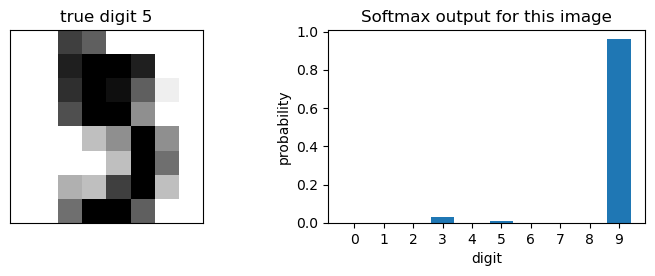

In [9]:
P = mlp_probs(digits_te0, digit_net)
wrong = np.where(P.argmax(axis=1) != yd_te)[0][:10]
fig, axes = plt.subplots(1, len(wrong), figsize=(15, 2.2))
for ax, i in zip(axes, wrong):
    ax.imshow(Xd_te[i].reshape(8, 8), cmap="gray_r")
    ax.set(title=f"true {yd_te[i]}, said {P[i].argmax()}\n({P[i].max():.0%} sure)", xticks=[], yticks=[])
plt.show()

i = wrong[0]
fig, axes = plt.subplots(1, 2, figsize=(9, 2.5))
axes[0].imshow(Xd_te[i].reshape(8, 8), cmap="gray_r")
axes[0].set(title=f"true digit {yd_te[i]}", xticks=[], yticks=[])
axes[1].bar(range(10), P[i])
axes[1].set(xticks=range(10), xlabel="digit", ylabel="probability", title="Softmax output for this image")
plt.show()

---
# Experiments
## 1. Scaling vs raw features (Wine, same start)

   raw: test accuracy  25.7%
scaled: test accuracy 100.0%


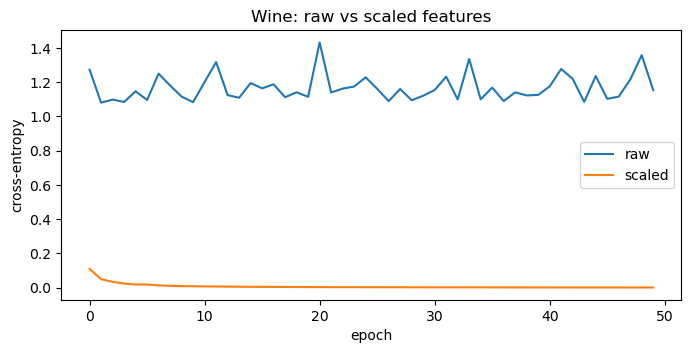

In [10]:
start = new_net(13, 10, 3)
fig, ax = plt.subplots(figsize=(8, 3.5))
for name, (a, b) in [("raw", (wine_tr_raw, wine_te_raw)), ("scaled", (Xtr_w, Xte_w))]:
    trained, loss_run = mlp_train(add_x0(a), ytr_w, start, 0.05, 50, show=False)
    print(f"{name:>6}: test accuracy {accuracy(add_x0(b), yte_w, trained):5.1f}%")
    ax.plot(loss_run, label=name)
ax.set(xlabel="epoch", ylabel="cross-entropy", title="Wine: raw vs scaled features")
ax.legend()
plt.show()

## 2. Hidden layer size (Digits, η = 0.02, 10 epochs)

hidden  2: test accuracy  52.6%
hidden  4: test accuracy  84.6%
hidden  8: test accuracy  93.8%
hidden 16: test accuracy  95.8%
hidden 32: test accuracy  95.8%
hidden 64: test accuracy  96.4%


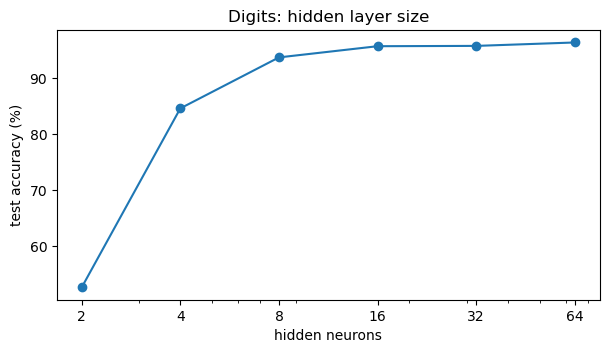

In [11]:
sizes = [2, 4, 8, 16, 32, 64]
test_accs = []
for hidden in sizes:
    trained, _ = mlp_train(digits_tr0, yd_tr, new_net(64, hidden, 10), 0.02, 10, show=False)
    test_accs.append(accuracy(digits_te0, yd_te, trained))
    print(f"hidden {hidden:>2}: test accuracy {test_accs[-1]:5.1f}%")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(sizes, test_accs, "o-")
ax.set(xscale="log", xticks=sizes, xticklabels=sizes, xlabel="hidden neurons", ylabel="test accuracy (%)",
       title="Digits: hidden layer size")
plt.show()

## 3. Learning rate (Digits, 32 hidden, same start, 10 epochs)

η = 0.0005: test accuracy  89.6%
η = 0.005 : test accuracy  94.5%
η = 0.02  : test accuracy  95.5%
η = 0.1   : test accuracy  95.2%
η = 1     : test accuracy  10.1%


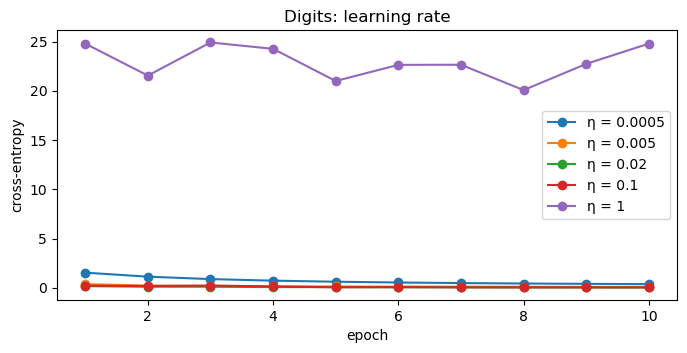

In [12]:
start = new_net(64, 32, 10)
fig, ax = plt.subplots(figsize=(8, 3.5))
for lr in [0.0005, 0.005, 0.02, 0.1, 1]:
    trained, loss_run = mlp_train(digits_tr0, yd_tr, start, lr, 10, show=False)
    print(f"η = {lr:<6}: test accuracy {accuracy(digits_te0, yd_te, trained):5.1f}%")
    ax.plot(range(1, 11), loss_run, "o-", label=f"η = {lr}")
ax.set(xlabel="epoch", ylabel="cross-entropy", title="Digits: learning rate")
ax.legend()
plt.show()

## Summary

In [13]:
print(f"{'dataset':>8} | {'features':>8} | {'classes':>7} | {'hidden':>6} | {'test acc':>8}")
print("-" * 50)
for name, net, X0, yy, nf, k, hidden in [
        ("Iris", iris_net, iris_te0, yte, 4, 3, 8),
        ("Wine", wine_net, wine_te0, yte_w, 13, 3, 10),
        ("Digits", digit_net, digits_te0, yd_te, 64, 10, 32)]:
    print(f"{name:>8} | {nf:>8} | {k:>7} | {hidden:>6} | {accuracy(X0, yy, net):7.1f}%")

 dataset | features | classes | hidden | test acc
--------------------------------------------------
    Iris |        4 |       3 |      8 |    96.7%
    Wine |       13 |       3 |     10 |   100.0%
  Digits |       64 |      10 |     32 |    96.5%


# Next folder: `03_Deep_Neural_Networks` — more than one hidden layer.